<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Grid and attractors
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N_nodes = 20
centers = np.random.choice(x, size=N_nodes, replace=False)
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
phi = sum(nodes)
history = [phi.copy()]


In [2]:
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t % 50 == 0:
        history.append(phi.copy())


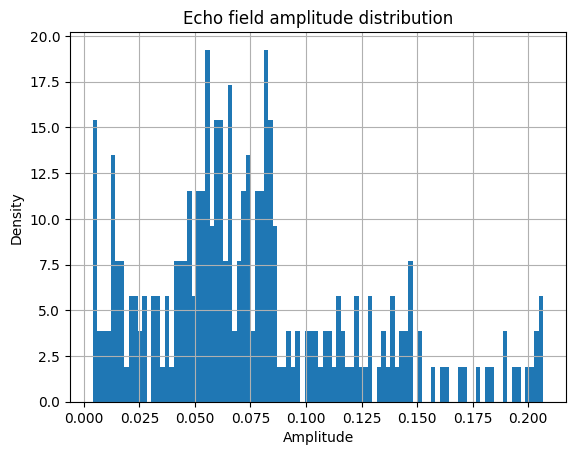

Detected quantized amplitude levels: [0.0130482  0.05567801 0.06582797 0.07394793 0.0820679 ]


In [3]:
# Final amplitude histogram
plt.hist(phi, bins=100, density=True)
plt.xlabel("Amplitude")
plt.ylabel("Density")
plt.title("Echo field amplitude distribution")
plt.grid(True)
plt.show()

# Optional: detect peaks
from scipy.signal import find_peaks

counts, bins = np.histogram(phi, bins=100)
peaks, _ = find_peaks(counts, prominence=5)
peak_positions = 0.5 * (bins[peaks] + bins[peaks+1])
print("Detected quantized amplitude levels:", peak_positions)
